# Workflow 5

This notebook is the first workflow as descrbed in this google document - https://docs.google.com/document/d/1qbmAjRa2V-anxj63YFFHdnovbY_U9MRi0uMAa4ZoCNg/edit.

The notebook merges the predictions (adjacent tiles) from SAM and does accuracy assessment.

In [1]:
#import sys
#sys.path.append('../')
from utils import *

# import required libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import os, glob, math, json
from matplotlib import pyplot as plt
from copy import deepcopy
from rtree import index
from geopandas.tools import sjoin
from shapely.geometry import box
from concurrent.futures import ThreadPoolExecutor
import time
import geoplanar
from datetime import datetime

today = datetime.now().strftime("%y%m%d")


# change the working directory
out_dir = r'D:\2212_PlanetOrtho_FieldBoundary\ForPaper\vector'
gt_file = r"D:\2212_PlanetOrtho_FieldBoundary\ForPaper\vector\GroundTruth\240805_GroundTruth_FieldBoundaries_PT_V2.shp"
os.chdir(out_dir)

## Merge predictions from original and edge enhanced images

In [2]:
%%time

COMPACTNESS_THRESHOLD = 0.5
previous_output = '240814_Workflow4_Output_v1'

# create folder
out_folder = os.path.join(out_dir, previous_output.replace('Workflow4', 'Workflow5'))
if not os.path.exists(out_folder):
    os.mkdir(out_folder)

# get the raw and edge enhanced final output
all_files = glob.glob(f'{previous_output}/*.gpkg')


# define a dataframe to store metrics
main_df = pd.DataFrame([], columns=['name', 'detected', 'detection_percentage', 'iou', 'precision', 'recall', 'f1score'])

test_gdf = pd.concat([read_file_with_name(file) for file in all_files])
test_gdf = test_gdf.explode(index_parts=True).reset_index(drop=True)
test_gdf = test_gdf.drop_duplicates(subset='geometry')
test_gdf = test_gdf[['name', 'geometry']]
test_gdf['ID_pred'] = test_gdf.index

"""
After combining predictions, there could be overlapping polygons, deal with them
"""
# take care of the polygons that are overlapped with their (almost!) duplicates
test_gdf = overlap_resolution_single(test_gdf)

# take care of the ones where small polygons are covered by large ones
test_gdf = trim_overlaps(test_gdf, largest=True).explode(index_parts=True)
test_gdf = test_gdf.loc[test_gdf.area > 100]

# geoplanar create island polygons inside polygons, deal with them

# geoplanar polygon cutting creates weird shapes, get rid of those
bounding_boxes = test_gdf.geometry.apply(lambda geom: geom.minimum_rotated_rectangle)
test_gdf['bbox_area'] = bounding_boxes.area.values
test_gdf['area'] = test_gdf.area.values
test_gdf['compactness'] = test_gdf.area / test_gdf.bbox_area
test_gdf['solidity'] = test_gdf.area / test_gdf.convex_hull.area

test_gdf = test_gdf[test_gdf.area / bounding_boxes.area >= COMPACTNESS_THRESHOLD]

# the previous step creates weird shapes, correct them
test_gdf['geometry'] = test_gdf.buffer(-2, join_style=3).buffer(2, join_style=3)
test_gdf = test_gdf.explode(index_parts=True)
test_gdf = test_gdf.loc[test_gdf.area > 100]

outfile1 = os.path.join(out_folder, f'AllTime_Segmented_Workflow5Merged_og.gpkg')

test_gdf.to_file(outfile1)

CPU times: total: 56.9 s
Wall time: 1min 58s


In [24]:
q = pd.concat([read_file_with_name(file) for file in all_files])

print(q.shape)

print(q.drop_duplicates(subset='geometry').shape)

(17357, 7)
(16707, 7)


<Axes: >

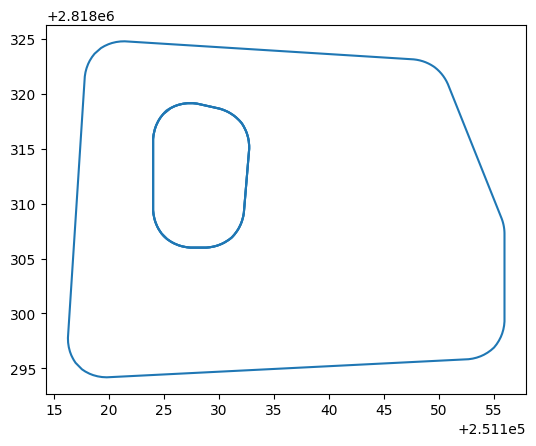

In [19]:
a = test_gdf.loc[test_gdf.ID_pred.isin([16814, 1103, 119])]
a.boundary.plot()

In [23]:
[a.within(geom) for geom in a.geometry]

[164    0  0     True
 1414   0  0     True
 29894  0  0    False
 dtype: bool,
 164    0  0     True
 1414   0  0     True
 29894  0  0    False
 dtype: bool,
 164    0  0    False
 1414   0  0    False
 29894  0  0     True
 dtype: bool]

In [ ]:
test_gdf['geometry'] = test_gdf.convex_hull

In [5]:
import geopandas as gpd
from shapely.strtree import STRtree

# Assuming 'test_gdf' is your GeoDataFrame
# Create an STRtree for spatial indexing
tree = STRtree(test_gdf['geometry'])

# Initialize a list to store the indices of polygons to keep
keep_indices = []

# Iterate over each polygon in the GeoDataFrame
for i, poly in test_gdf.iterrows():
    # Query the spatial index for potential containing polygons (return geometries directly)
    possible_matches = [test_gdf.iloc[idx].geometry for idx in tree.query(poly.geometry)]

    # Check if the polygon is within any of the possible matches
    is_within_any = any(poly.geometry.within(match) for match in possible_matches if not match.equals(poly.geometry))
    
    if not is_within_any:
        keep_indices.append(i)

# Filter the GeoDataFrame to keep only polygons that are not within any other polygon
test_gdf_filtered = test_gdf.loc[keep_indices]

test_gdf_filtered

,,index,name,ID_pred,geometry
0,0,0,AllTime_Enhanced_Segmented_Workflow4Merged.gpkg,0,"POLYGON ((251941.676 2817918.928, 251941.017 2..."
1,0,1,AllTime_Enhanced_Segmented_Workflow4Merged.gpkg,1,"POLYGON ((251973.705 2817882, 251973.245 28178..."
2,0,2,AllTime_Enhanced_Segmented_Workflow4Merged.gpkg,2,"POLYGON ((252100.344 2817871.577, 252100.322 2..."
3,0,3,AllTime_Enhanced_Segmented_Workflow4Merged.gpkg,3,"POLYGON ((251933.929 2817710.955, 251928.598 2..."
4,0,4,AllTime_Enhanced_Segmented_Workflow4Merged.gpkg,4,"POLYGON ((252010.342 2817706, 252009.559 28177..."
...,...,...,...,...,...
31137,0,17348,AllTime_Segmented_Workflow4Merged.gpkg,17348,"POLYGON ((252167.28 2818550, 252166.878 281855..."
31138,0,17349,AllTime_Segmented_Workflow4Merged.gpkg,17349,"POLYGON ((252179.818 2818327.455, 252166.75 28..."
31142,0,17352,AllTime_Segmented_Workflow4Merged.gpkg,17352,"POLYGON ((252536.559 2818169, 252535.2 2818169..."
31143,0,17353,AllTime_Segmented_Workflow4Merged.gpkg,17353,"POLYGON ((252323.977 2817909, 252323.253 28179..."


In [10]:
test_gdf_filtered.to_file(outfile1)

In [7]:
test_gdf.shape

(11600, 4)

## Acc Ass same as previous workflows

In [10]:
%%time

# get a list of all the files
files_list = glob.glob(f"{out_folder}/*.gpkg")

# create an empty DF to store metrics
metrics_df = pd.DataFrame(columns=['File', 'Precision', 'Recall', 'F1-Score', 'Detection', 'IoU'])

# loop through all the files and caculate metrics
for n, file in enumerate(files_list):
    print(os.path.split(file)[-1], f'{n}/{len(files_list)}..')
    
    """
    prepare the ground truth shapefile
    """
    gt_gdf = gpd.read_file(gt_file)
    gt_gdf['ID_gt'] = gt_gdf.index

    # add new cols in the ground truth gdf to calculate metrics later
    for new_col in ['max_overlap_id', 'iou', 'precision', 'recall', 'f1score']:
        gt_gdf[new_col] = -1 

    # remove empty geometries
    gt_gdf = gt_gdf.loc[
        (gt_gdf.geom_type.isin(['Polygon', 'MultiPolygon']))
    ]

    """
    read the predicted data
    """
    # read the predicted file
    pred_gdf = gpd.read_file(file)
    
    """
    calculate tota area based metrics
    """
    intersection_area = gt_gdf.dissolve().intersection(pred_gdf.dissolve()).area[0]
    union_area = gt_gdf.dissolve().union(pred_gdf.dissolve()).area[0]

    precision = round(intersection_area / pred_gdf.dissolve().area[0], 3)
    recall = round(intersection_area / gt_gdf.dissolve().area[0], 3)
    f1_score = round(2 * (precision * recall) / (precision + recall), 3)

    """
    calculate number of polygons detected
    """
    # Create spatial index for test layer for faster processing
    # can't craete this inside the function because it is unnecessary time wastage
    spatial_index = index.Index()
    for i, geometry in enumerate(pred_gdf.geometry):
        if len(geometry.bounds) > 0:
            spatial_index.insert(i, geometry.bounds)

    # for each polygon in the ground truth, find polygon in the test file that has IoU greater than 0.5
    gt_gdf = gt_gdf.apply(lambda row: wflow1_iou_threshold_metrics(row, gt_gdf, deepcopy(pred_gdf), spatial_index,
                                                                  threshold=0.5), axis=1)

    # calculate the precision for this test layer (how many polygons are identified)
    detection_percentage = round(100 * gt_gdf.loc[gt_gdf['max_overlap_id'] != -1].shape[0] / gt_gdf.shape[0], 3)
    detected_iou = round(gt_gdf.loc[gt_gdf['max_overlap_id'] != -1, 'iou'].mean(), 3)

    metrics_dict = {
            'File': [os.path.split(file)[-1]],
            'Precision': [precision],
            'Recall': [recall],
            'F1-Score': [f1_score],
            'Detection': [detection_percentage],
            'IoU': [detected_iou]
        }

    metrics_df = pd.concat([
        metrics_df, 
        pd.DataFrame(metrics_dict)
    ], axis=0)

    metrics_df.to_csv(f"D:/2212_PlanetOrtho_FieldBoundary/ForPaper/tables/{today}_Workflow5Metrics_v1.csv", index=False)

AllTime_Segmented_Workflow5Merged.gpkg 0/1..
CPU times: total: 13.4 s
Wall time: 40 s


<timed exec>:69: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
